# Notebook 3 - Analisis del Dato

Este cuaderno inicia la fase de Analisis del Dato a partir del dataset municipal enriquecido generado en la fase de Ingenieria del Dato.

La unidad de observacion original del proyecto es `municipio-dia`. No obstante, en este notebook se combinan dos niveles de trabajo:
- el nivel diario, para revisar comportamiento temporal y estacionalidad;
- y el nivel municipal agregado, para comparar municipios, construir indicadores climaticos, territoriales y de exposicion fisica, y preparar una base analitica util para fases posteriores de segmentacion e interpretacion.

La entrada principal del notebook es:

`DATA/PROCESSED/dataset_cv_municipios_enriched.csv`

Adicionalmente, si se encuentran disponibles, se incorporan salidas complementarias ya consolidadas en Ingenieria del Dato:

- altitud aproximada de la coordenada `ERA5-Land` asociada a cada municipio: `DATA/PROCESSED/municipios_altitud_openmeteo.csv`;
- variables climaticas extendidas de `ERA5-Land`: `DATA/PROCESSED/dataset_cv_municipios_climate_extended.csv`;
- resumen municipal de exposicion edificada procedente de Catastro: `DATA/PROCESSED/catastro_buildings_cv_summary.csv`.

Este cuaderno no construye de nuevo el pipeline `ETL`, sino que parte de las salidas ya consolidadas en Ingenieria del Dato para centrarse en el analisis descriptivo, la comparacion territorial y la construccion de indicadores exploratorios.

## 0. Configuracion inicial

En este bloque se cargan las librerias necesarias y se definen las rutas de trabajo. El objetivo es garantizar que el notebook pueda ejecutarse de forma reproducible sobre las salidas ya generadas en la fase anterior.

Ademas, se referencian los principales ficheros de entrada y la salida municipal agregada que se generara durante este analisis.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "DATA"
PROC = DATA / "PROCESSED"
EXT = DATA / "EXTERNAL"
OUT = ROOT / "output"
MAPS = OUT / "maps"

DATASET_FILE = PROC / "dataset_cv_municipios_enriched.csv"
ALTITUDE_FILE = PROC / "municipios_altitud_openmeteo.csv"
CLIMATE_EXTENDED_FILE = PROC / "dataset_cv_municipios_climate_extended.csv"
CATASTRO_SUMMARY_FILE = PROC / "catastro_buildings_cv_summary.csv"
MUNICIPIOS_GEO_FILE = EXT / "municipios_cv.geojson"

ANALYTIC_MUNICIPAL_FILE = PROC / "dataset_cv_municipios_analisis_municipal.csv"

MAPS.mkdir(parents=True, exist_ok=True)

print("Dataset de analisis:", DATASET_FILE)
print("Existe:", DATASET_FILE.exists())
print("Altitud disponible:", ALTITUDE_FILE.exists())
print("ERA5-Land extendido disponible:", CLIMATE_EXTENDED_FILE.exists())
print("Catastro municipal disponible:", CATASTRO_SUMMARY_FILE.exists())
print("Geometria municipal disponible:", MUNICIPIOS_GEO_FILE.exists())
print("Salida municipal agregada:", ANALYTIC_MUNICIPAL_FILE)

Dataset de analisis: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_enriched.csv
Existe: True
Altitud disponible: True
ERA5-Land extendido disponible: True
Catastro municipal disponible: True
Geometria municipal disponible: True
Salida municipal agregada: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_analisis_municipal.csv


## 1. Carga del dataset y comprobaciones basicas

El primer paso consiste en cargar el dataset enriquecido y verificar que conserva la estructura esperada tras la fase de Ingenieria del Dato. En particular, interesa comprobar la cobertura territorial y temporal, la unicidad de la clave `municipio-fecha` y la presencia de valores nulos en las variables principales.

Esta revision inicial actua como control de consistencia antes de avanzar hacia el analisis descriptivo y la construccion de indicadores agregados.


In [2]:
df = pd.read_csv(DATASET_FILE, parse_dates=["fecha"])
df["cod_ine"] = df["cod_ine"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(5)

print("Shape:", df.shape)
print("Municipios:", df["municipio"].nunique())
print("Rango temporal:", df["fecha"].min().date(), "->", df["fecha"].max().date())
print("Dias unicos:", df["fecha"].nunique())
print("Duplicados municipio-fecha:", df.duplicated(subset=["municipio", "fecha"]).sum())

assert df["municipio"].nunique() == 542, "El dataset debe mantener los 542 municipios de la Comunidad Valenciana."
assert df["fecha"].nunique() == 2192, "El periodo esperado es 2019-2024 completo a escala diaria."
assert df.duplicated(subset=["municipio", "fecha"]).sum() == 0, "Hay duplicados municipio-fecha."

display(df.head())

Shape: (1188064, 22)
Municipios: 542


Rango temporal: 2019-01-01 -> 2024-12-31
Dias unicos: 2192


Duplicados municipio-fecha: 0


,municipio,CODNUT2,CODNUT3,fecha,temp_media_dia,temp_max_dia,temp_min_dia,viento_medio_dia,viento_max_dia,lon,lat,dist_metros,precip_total_dia,amplitud_termica_dia,area_km2,cod_ine,poblacion_total,densidad_poblacion,mayores_65_pct,menores_16_pct,indice_envejecimiento,renta_media_hogar
0,Ademuz,ES52,ES523,2019-01-01,2.735280,12.305084,-2.840179,1.430405,1.927332,-1.2,40.1,5806.682345,0.000000,15.145263,100.29,46001,1015.0,10.12,26.8,11.82,226.67,27809.0
1,Ademuz,ES52,ES523,2019-01-02,1.408661,8.768463,-2.744965,2.487614,3.134458,-1.2,40.1,5806.682345,0.000860,11.513428,100.29,46001,1015.0,10.12,26.8,11.82,226.67,27809.0
2,Ademuz,ES52,ES523,2019-01-03,1.463847,7.518707,-3.328705,1.271294,1.983465,-1.2,40.1,5806.682345,0.000000,10.847412,100.29,46001,1015.0,10.12,26.8,11.82,226.67,27809.0
3,Ademuz,ES52,ES523,2019-01-04,1.935232,10.640778,-4.029633,1.283369,1.690730,-1.2,40.1,5806.682345,0.000852,14.670411,100.29,46001,1015.0,10.12,26.8,11.82,226.67,27809.0
4,Ademuz,ES52,ES523,2019-01-05,1.852412,10.552155,-4.144867,2.385710,3.107875,-1.2,40.1,5806.682345,0.000000,14.697022,100.29,46001,1015.0,10.12,26.8,11.82,226.67,27809.0


In [3]:
expected_rows = df["municipio"].nunique() * df["fecha"].nunique()

print("Filas esperadas:", expected_rows)
print("Filas reales:", len(df))
print("Cobertura completa:", expected_rows == len(df))

assert expected_rows == len(df), "La cobertura municipio-dia no esta completa."

id_cols = ["municipio", "CODNUT2", "CODNUT3", "fecha"]

climate_cols = [
    "precip_total_dia",
    "temp_media_dia",
    "temp_max_dia",
    "temp_min_dia",
    "viento_medio_dia",
    "viento_max_dia",
    "amplitud_termica_dia",
]

spatial_cols = ["lon", "lat", "dist_metros", "area_km2"]

territorial_cols = [
    "cod_ine",
    "poblacion_total",
    "densidad_poblacion",
    "mayores_65_pct",
    "menores_16_pct",
    "indice_envejecimiento",
    "renta_media_hogar",
]

print("Variables totales:", len(df.columns))
print("Variables identificadoras:", len(id_cols))
print("Variables climaticas:", len(climate_cols))
print("Variables espaciales:", len(spatial_cols))
print("Variables territoriales:", len(territorial_cols))

Filas esperadas: 1188064
Filas reales: 1188064
Cobertura completa: True
Variables totales: 22
Variables identificadoras: 4
Variables climaticas: 7
Variables espaciales: 4
Variables territoriales: 7


In [4]:
missing = (
    df[id_cols + climate_cols + spatial_cols + territorial_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("nulos")
)
missing["pct"] = (missing["nulos"] / len(df) * 100).round(3)

critical_cols = id_cols + climate_cols + spatial_cols
assert missing.loc[critical_cols, "nulos"].sum() == 0, "Hay nulos en variables criticas del analisis."

display(missing[missing["nulos"] > 0])

print("Filas con algun nulo:", df.isna().any(axis=1).sum())
print("Porcentaje de filas con algun nulo:", round(df.isna().any(axis=1).mean() * 100, 3), "%")

,nulos,pct
renta_media_hogar,17536,1.476
indice_envejecimiento,10960,0.923


Filas con algun nulo: 21920


Porcentaje de filas con algun nulo: 1.845 %


La comprobacion inicial confirma que el dataset mantiene la cobertura esperada para `542` municipios y el periodo completo `2019-2024`, sin duplicados en la clave `municipio-fecha`. Ademas, el numero total de filas coincide con la combinacion esperada de municipios y dias, lo que refuerza la consistencia estructural de la base.

Los valores nulos se concentran en un numero reducido de variables territoriales del bloque `INE`, especialmente `renta_media_hogar` e `indice_envejecimiento`. Dado que se trata de variables estaticas replicadas sobre la dimension temporal, su volumen aparente en filas es superior al numero real de municipios afectados. En cualquier caso, esta incidencia no compromete el bloque climatico principal ni impide continuar con el analisis descriptivo y la agregacion municipal.


## 2. Incorporacion de altitud aproximada

En este bloque se incorpora una variable adicional de altitud a escala municipal. No obstante, esta altitud no representa la elevacion media real de todo el termino municipal, sino la altitud aproximada de la coordenada `ERA5-Land` asignada a cada municipio en la fase de Ingenieria del Dato.

Por tanto, debe interpretarse como una variable auxiliar de contexto fisico, util para apoyar la lectura de diferencias climaticas entre zonas litorales, interiores y de mayor elevacion, pero no como una caracterizacion topografica exhaustiva del municipio.



In [5]:
if ALTITUDE_FILE.exists():
    df_alt = pd.read_csv(ALTITUDE_FILE)
    altitude_cols = ["municipio", "CODNUT2", "CODNUT3", "altitud_m"]
    df_alt = df_alt[altitude_cols].drop_duplicates(subset=["municipio", "CODNUT2", "CODNUT3"])

    df = df.merge(df_alt, on=["municipio", "CODNUT2", "CODNUT3"], how="left")
    print("Altitud incorporada.")
    print("Municipios con altitud:", df.groupby("municipio")["altitud_m"].first().notna().sum())
    print("Municipios sin altitud:", df.groupby("municipio")["altitud_m"].first().isna().sum())
    print("Resumen altitud:")
    display(df[["municipio", "altitud_m"]].drop_duplicates()["altitud_m"].describe())
else:
    df["altitud_m"] = np.nan
    print("No se encontro fichero de altitud. El analisis continua sin esta variable.")

display(df[["municipio", "lat", "lon", "altitud_m"]].drop_duplicates().head())


Altitud incorporada.
Municipios con altitud: 542


Municipios sin altitud: 0
Resumen altitud:


count     542.000000
mean      384.656827
std       327.369029
min        -2.000000
25%        81.000000
50%       328.000000
75%       621.750000
max      1374.000000
Name: altitud_m, dtype: float64

,municipio,lat,lon,altitud_m
0,Ademuz,40.1,-1.2,907.0
2192,Ador,38.9,-0.2,79.0
4384,Agost,38.4,-0.6,181.0
6576,Agres,38.8,-0.5,756.0
8768,Agullent,38.8,-0.6,556.0


La incorporacion de altitud queda resuelta para la totalidad de los municipios analizados, por lo que esta variable puede utilizarse en los bloques posteriores de correlacion, interpretacion territorial y representacion espacial.

Aun asi, conviene recordar que varios municipios pueden compartir la misma coordenada `ERA5-Land` y, por tanto, la misma altitud aproximada. En consecuencia, esta variable debe entenderse como una ayuda interpretativa coherente con la resolucion espacial del dataset, no como una medida topografica municipal de alta precision.


## 3. Analisis temporal de variables climaticas

Se agregan las observaciones diarias a escala mensual para observar tendencias generales y estacionalidad. Este analisis sirve para comprobar si las variables tienen un comportamiento climatologico plausible antes de pasar a indicadores municipales.


In [6]:
df_month = (
    df.assign(mes=df["fecha"].dt.to_period("M").dt.to_timestamp())
    .groupby("mes", as_index=False)
    .agg(
        precip_media_diaria=("precip_total_dia", "mean"),
        temp_media=("temp_media_dia", "mean"),
        temp_max_media=("temp_max_dia", "mean"),
        viento_medio=("viento_medio_dia", "mean"),
    )
)

display(df_month.head())

,mes,precip_media_diaria,temp_media,temp_max_media,viento_medio
0,2019-01-01,0.146805,8.007917,13.462288,2.994654
1,2019-02-01,0.117051,9.741801,16.063344,2.577584
2,2019-03-01,0.877532,12.402223,18.518076,2.625422
3,2019-04-01,4.494653,13.049360,17.745502,3.150904
4,2019-05-01,0.972821,16.950787,22.141527,2.411726


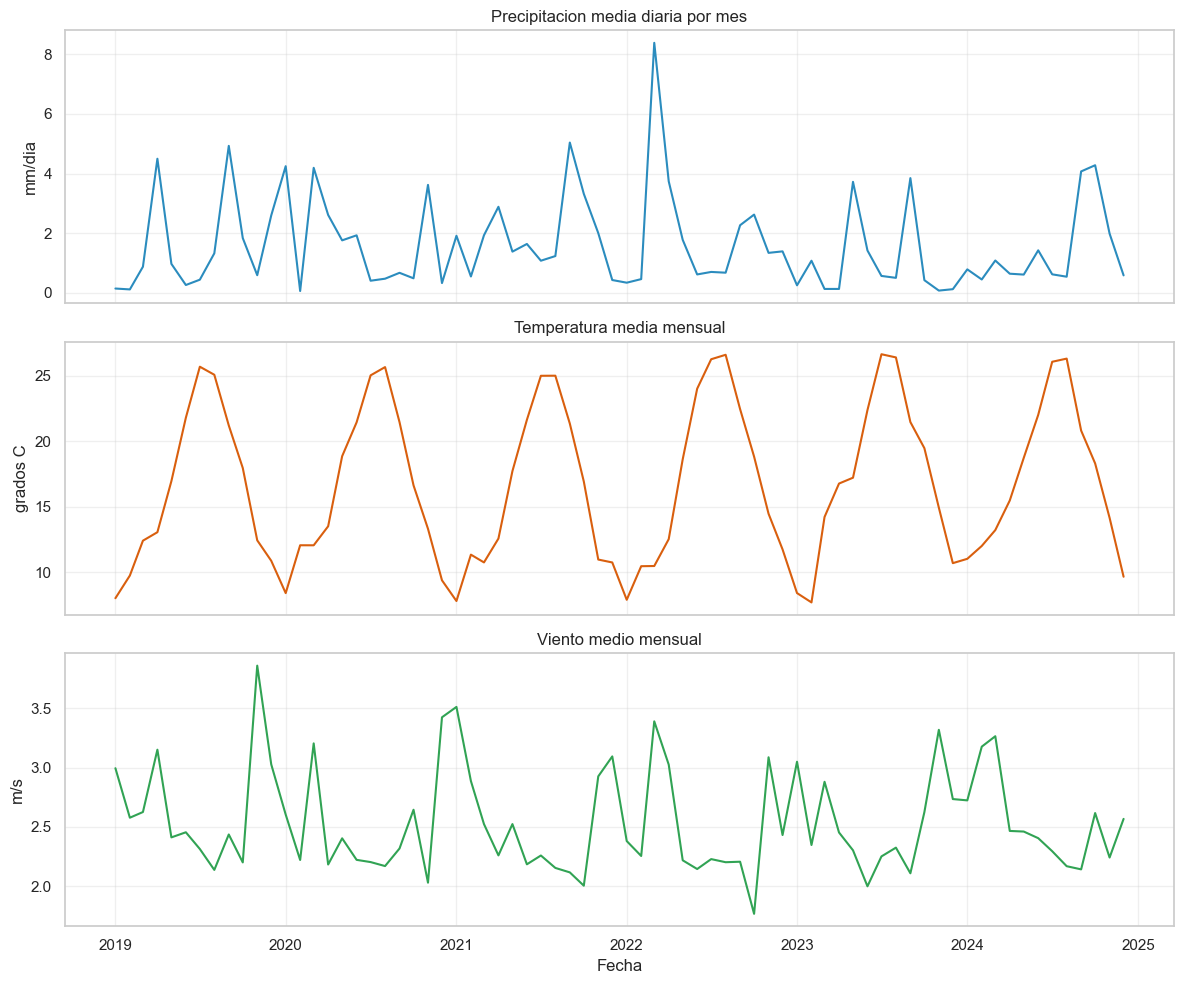

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df_month["mes"], df_month["precip_media_diaria"], color="#2b8cbe")
axes[0].set_title("Precipitacion media diaria por mes")
axes[0].set_ylabel("mm/dia")

axes[1].plot(df_month["mes"], df_month["temp_media"], color="#d95f0e")
axes[1].set_title("Temperatura media mensual")
axes[1].set_ylabel("grados C")

axes[2].plot(df_month["mes"], df_month["viento_medio"], color="#31a354")
axes[2].set_title("Viento medio mensual")
axes[2].set_ylabel("m/s")
axes[2].set_xlabel("Fecha")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
month_names = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}

df_seasonality = (
    df.assign(mes_num=df["fecha"].dt.month)
    .groupby("mes_num", as_index=False)
    .agg(
        precip_media_diaria=("precip_total_dia", "mean"),
        temp_media=("temp_media_dia", "mean"),
        viento_medio=("viento_medio_dia", "mean"),
    )
)

df_seasonality["mes"] = df_seasonality["mes_num"].map(month_names)

display(df_seasonality[["mes", "precip_media_diaria", "temp_media", "viento_medio"]])


,mes,precip_media_diaria,temp_media,viento_medio
0,Ene,1.282057,8.584712,2.877358
1,Feb,0.451260,10.562452,2.578834
2,Mar,2.765949,12.180525,2.981311
3,Abr,2.417854,13.977894,2.589740
4,May,1.704774,18.012521,2.386926
5,Jun,1.216731,22.209235,2.235231
6,Jul,0.637397,25.778980,2.258562
7,Ago,0.793609,25.839345,2.193058
8,Sep,3.469974,21.453574,2.221468
9,Oct,2.162147,18.015580,2.309752


La agregacion temporal confirma un comportamiento climatologico coherente en las variables principales del dataset. La temperatura presenta una estacionalidad clara, con valores mas altos en los meses de verano y mas bajos en invierno. La precipitacion muestra mayor irregularidad, con repuntes mas intensos en determinados meses, especialmente en el entorno del otoño mediterraneo. El viento, por su parte, presenta una variacion mas moderada que la precipitacion y menos marcada que la temperatura.

En conjunto, este bloque refuerza la plausibilidad del dataset construido y justifica avanzar hacia una comparacion territorial a escala municipal.


## 4. Agregacion municipal e indicadores climaticos

Para comparar municipios se transforma el dataset diario en una tabla agregada a escala municipal. En este bloque se calculan indicadores medios, extremos y de frecuencia de eventos intensos, con el objetivo de resumir el comportamiento climático de cada municipio durante el periodo completo de estudio.

Se combinan dos tipos de indicadores:
- indicadores internos al municipio, como medias, máximos y percentiles propios;
- e indicadores basados en umbrales globales, que permiten comparar todos los municipios bajo un mismo criterio de intensidad.



In [9]:
thresholds = {
    "precip_p95_global": df["precip_total_dia"].quantile(0.95),
    "precip_p99_global": df["precip_total_dia"].quantile(0.99),
    "temp_max_p95_global": df["temp_max_dia"].quantile(0.95),
    "viento_max_p95_global": df["viento_max_dia"].quantile(0.95),
}

for name, value in thresholds.items():
    print(f"{name}: {value:.3f}")

precip_p95_global: 8.816
precip_p99_global: 27.111
temp_max_p95_global: 33.130
viento_max_p95_global: 7.076


In [10]:
df_mun = (
    df.groupby(["municipio", "CODNUT2", "CODNUT3"], as_index=False)
    .agg(
        precip_media_diaria=("precip_total_dia", "mean"),
        precip_max_dia=("precip_total_dia", "max"),
        precip_p95=("precip_total_dia", lambda s: s.quantile(0.95)),
        precip_p99=("precip_total_dia", lambda s: s.quantile(0.99)),
        dias_precip_intensa=("precip_total_dia", lambda s: (s >= thresholds["precip_p95_global"]).sum()),
        dias_precip_extrema=("precip_total_dia", lambda s: (s >= thresholds["precip_p99_global"]).sum()),
        temp_media_periodo=("temp_media_dia", "mean"),
        temp_max_media=("temp_max_dia", "mean"),
        temp_max_abs=("temp_max_dia", "max"),
        temp_p95=("temp_max_dia", lambda s: s.quantile(0.95)),
        dias_calor_intenso=("temp_max_dia", lambda s: (s >= thresholds["temp_max_p95_global"]).sum()),
        temp_min_abs=("temp_min_dia", "min"),
        viento_medio_periodo=("viento_medio_dia", "mean"),
        viento_max_abs=("viento_max_dia", "max"),
        viento_p95=("viento_max_dia", lambda s: s.quantile(0.95)),
        dias_viento_intenso=("viento_max_dia", lambda s: (s >= thresholds["viento_max_p95_global"]).sum()),
        amplitud_termica_media=("amplitud_termica_dia", "mean"),
        lon=("lon", "first"),
        lat=("lat", "first"),
        dist_metros=("dist_metros", "first"),
        area_km2=("area_km2", "first"),
        cod_ine=("cod_ine", "first"),
        poblacion_total=("poblacion_total", "first"),
        densidad_poblacion=("densidad_poblacion", "first"),
        mayores_65_pct=("mayores_65_pct", "first"),
        menores_16_pct=("menores_16_pct", "first"),
        indice_envejecimiento=("indice_envejecimiento", "first"),
        renta_media_hogar=("renta_media_hogar", "first"),
        altitud_m=("altitud_m", "first"),
    )
)

print("Shape agregado municipal:", df_mun.shape)
display(df_mun.head())
print("Municipios unicos en agregado:", df_mun["municipio"].nunique())
print("Duplicados municipales:", df_mun.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum())


Shape agregado municipal: (542, 32)


,municipio,CODNUT2,CODNUT3,precip_media_diaria,precip_max_dia,precip_p95,precip_p99,dias_precip_intensa,dias_precip_extrema,temp_media_periodo,temp_max_media,temp_max_abs,temp_p95,dias_calor_intenso,temp_min_abs,viento_medio_periodo,viento_max_abs,viento_p95,dias_viento_intenso,amplitud_termica_media,lon,lat,dist_metros,area_km2,cod_ine,poblacion_total,densidad_poblacion,mayores_65_pct,menores_16_pct,indice_envejecimiento,renta_media_hogar,altitud_m
0,Ademuz,ES52,ES523,1.459790,33.931183,8.618695,18.368174,105,6,12.317326,17.969816,37.645905,32.069465,60,-9.880951,2.354678,9.956327,6.782720,78,10.909306,-1.2,40.1,5806.682345,100.2900,46001,1015.0,10.12,26.80,11.82,226.67,27809.0,907.0
1,Ador,ES52,ES523,2.102830,143.414780,11.106972,37.833611,138,38,17.895431,21.608291,39.722076,31.999384,68,1.046295,3.106088,13.624233,7.682318,179,7.251112,-0.2,38.9,2485.383043,13.8364,46002,1755.0,126.84,20.42,11.36,179.70,31572.0,79.0
2,Agost,ES52,ES521,1.094086,75.414550,5.610108,18.520694,75,11,18.075257,22.611731,39.302155,32.961835,97,-0.357025,2.732337,13.176444,7.184352,117,8.828438,-0.6,38.4,6996.059580,66.6538,03002,5225.0,78.39,20.27,13.84,146.47,30407.0,181.0
3,Agres,ES52,ES521,1.826327,106.037970,9.551134,31.017301,123,28,16.650944,22.090261,42.157623,34.419501,176,-3.486420,1.976098,9.044077,5.725050,22,10.334956,-0.5,38.8,2075.930152,25.8457,03003,623.0,24.10,24.80,11.36,218.31,31440.0,756.0
4,Agullent,ES52,ES523,1.690449,98.432850,9.223645,28.305807,113,25,16.429414,22.035266,42.036530,34.757147,200,-3.988373,1.995531,9.247415,5.912659,29,10.584102,-0.6,38.8,5559.636342,16.2440,46004,2438.0,150.09,21.43,12.46,172.04,31085.0,556.0


Municipios unicos en agregado: 542
Duplicados municipales: 0


### 4.1 Incorporacion de variables complementarias

Una vez construida la tabla municipal basica, se incorporan dos salidas adicionales de Ingenieria del Dato. Las variables extendidas de `ERA5-Land` aportan contexto fisico sobre humedad, radiacion, presion y escorrentia. El resumen de Catastro aporta una aproximacion a la exposicion edificada de cada municipio. Ambas capas se integran a escala municipal para no duplicar informacion diaria innecesariamente.

In [11]:
mun_keys = ["municipio", "CODNUT2", "CODNUT3"]

if CLIMATE_EXTENDED_FILE.exists():
    ext_usecols = [
        "municipio", "CODNUT2", "CODNUT3", "fecha",
        "dewpoint_media_dia", "dewpoint_max_dia",
        "presion_superficie_media_hpa",
        "runoff_superficial_total_dia_mm",
        "humedad_suelo_capa1_media_m3_m3",
        "radiacion_solar_total_dia_mj_m2",
    ]
    df_ext = pd.read_csv(CLIMATE_EXTENDED_FILE, usecols=ext_usecols, parse_dates=["fecha"])

    print("ERA5-Land extendido cargado:", df_ext.shape)
    print("Municipios:", df_ext["municipio"].nunique())
    print("Rango temporal:", df_ext["fecha"].min().date(), "->", df_ext["fecha"].max().date())

    assert df_ext["municipio"].nunique() == df_mun["municipio"].nunique(), "La capa extendida no cubre todos los municipios."
    assert df_ext.duplicated(subset=["municipio", "fecha"]).sum() == 0, "Hay duplicados municipio-fecha en ERA5-Land extendido."

    ext_thresholds = {
        "runoff_p95_global": df_ext["runoff_superficial_total_dia_mm"].quantile(0.95),
        "soil_p10_global": df_ext["humedad_suelo_capa1_media_m3_m3"].quantile(0.10),
        "radiation_p90_global": df_ext["radiacion_solar_total_dia_mj_m2"].quantile(0.90),
    }

    df_ext_mun = (
        df_ext.groupby(mun_keys, as_index=False)
        .agg(
            dewpoint_media_periodo=("dewpoint_media_dia", "mean"),
            dewpoint_p95=("dewpoint_max_dia", lambda s: s.quantile(0.95)),
            presion_superficie_media_periodo_hpa=("presion_superficie_media_hpa", "mean"),
            runoff_total_periodo_mm=("runoff_superficial_total_dia_mm", "sum"),
            runoff_p95_dia_mm=("runoff_superficial_total_dia_mm", lambda s: s.quantile(0.95)),
            dias_runoff_extremo=("runoff_superficial_total_dia_mm", lambda s: (s >= ext_thresholds["runoff_p95_global"]).sum()),
            humedad_suelo_media_periodo=("humedad_suelo_capa1_media_m3_m3", "mean"),
            humedad_suelo_p05=("humedad_suelo_capa1_media_m3_m3", lambda s: s.quantile(0.05)),
            dias_suelo_seco=("humedad_suelo_capa1_media_m3_m3", lambda s: (s <= ext_thresholds["soil_p10_global"]).sum()),
            radiacion_solar_media_periodo_mj_m2=("radiacion_solar_total_dia_mj_m2", "mean"),
            radiacion_solar_p95_mj_m2=("radiacion_solar_total_dia_mj_m2", lambda s: s.quantile(0.95)),
            dias_radiacion_alta=("radiacion_solar_total_dia_mj_m2", lambda s: (s >= ext_thresholds["radiation_p90_global"]).sum()),
        )
    )

    before_rows = len(df_mun)
    df_mun = df_mun.merge(df_ext_mun, on=mun_keys, how="left", validate="one_to_one")
    assert len(df_mun) == before_rows, "El merge con ERA5-Land extendido ha cambiado el numero de municipios."
    print("Variables ERA5-Land extendidas incorporadas:", len(df_ext_mun.columns) - len(mun_keys))
    del df_ext
else:
    print("No se encontro ERA5-Land extendido. El analisis continua con las variables climaticas base.")

if CATASTRO_SUMMARY_FILE.exists():
    catastro_cols = [
        "cod_ine", "catastro_code", "catastro_name",
        "num_edificios_catastro", "num_partes_edificio_catastro", "num_otras_construcciones_catastro",
        "huella_edificada_m2", "superficie_construida_catastro_m2",
        "num_unidades_edificatorias_catastro", "num_viviendas_catastro",
        "superficie_media_huella_edificio_m2", "superficie_media_construida_edificio_m2",
        "densidad_edificios_km2", "densidad_viviendas_catastro_km2",
        "ratio_huella_edificada_pct", "intensidad_constructiva_m2_km2",
        "superficie_otras_construcciones_m2",
    ]
    df_catastro = pd.read_csv(CATASTRO_SUMMARY_FILE, usecols=catastro_cols)
    df_catastro["cod_ine"] = df_catastro["cod_ine"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(5)
    df_catastro = df_catastro.drop_duplicates(subset=["cod_ine"])

    before_rows = len(df_mun)
    df_mun = df_mun.merge(df_catastro, on="cod_ine", how="left", validate="one_to_one")
    assert len(df_mun) == before_rows, "El merge con Catastro ha cambiado el numero de municipios."
    print("Variables de Catastro incorporadas:", len(df_catastro.columns) - 1)
    print("Municipios sin Catastro:", df_mun["catastro_code"].isna().sum())
else:
    print("No se encontro el resumen de Catastro. El analisis continua sin exposicion edificada.")

assert len(df_mun) == 542, "La tabla municipal debe conservar 542 municipios."
assert df_mun.duplicated(subset=mun_keys).sum() == 0, "Hay duplicados en la tabla municipal final."

preview_cols = [
    "municipio", "cod_ine", "precip_p99", "temp_p95", "viento_p95",
    "humedad_suelo_media_periodo", "radiacion_solar_media_periodo_mj_m2",
    "densidad_edificios_km2", "ratio_huella_edificada_pct",
]
preview_cols = [col for col in preview_cols if col in df_mun.columns]
display(df_mun[preview_cols].head())

ERA5-Land extendido cargado: (1188064, 10)
Municipios: 542
Rango temporal: 2019-01-01 -> 2024-12-31


Variables ERA5-Land extendidas incorporadas: 12
Variables de Catastro incorporadas: 16
Municipios sin Catastro: 0


,municipio,cod_ine,precip_p99,temp_p95,viento_p95,humedad_suelo_media_periodo,radiacion_solar_media_periodo_mj_m2,densidad_edificios_km2,ratio_huella_edificada_pct
0,Ademuz,46001,18.368174,32.069465,6.782720,0.256154,17.075737,20.51,0.1728
1,Ador,46002,37.833611,31.999384,7.682318,0.241087,17.545751,65.19,1.0499
2,Agost,03002,18.520694,32.961835,7.184352,0.108358,18.002993,35.77,0.8237
3,Agres,03003,31.017301,34.419501,5.725050,0.241691,17.565828,25.65,0.4122
4,Agullent,46004,28.305807,34.757147,5.912659,0.226860,17.509921,78.74,2.7882


El resultado de este bloque es una tabla municipal resumida que transforma la informacion diaria en indicadores comparables entre municipios. Esta agregacion permite pasar de una lectura temporal a una lectura territorial del problema, incorporando tanto el peligro climatico base como variables fisicas complementarias y exposicion edificada cuando estas capas estan disponibles.

## 5. Distribuciones y rankings municipales

Una vez construida la tabla municipal agregada, el siguiente paso consiste en analizar la distribucion de los indicadores principales y detectar municipios o grupos de municipios que destacan por valores especialmente altos en variables climaticas y territoriales.

Este bloque cumple una doble funcion. Por un lado, permite comprobar si los indicadores presentan distribuciones razonables o fuertemente asimetricas, algo relevante para la interpretacion posterior y para posibles modelos de segmentacion. Por otro, permite identificar territorios que concentran mayor intensidad o frecuencia de eventos climaticos, asi como municipios con caracteristicas territoriales potencialmente mas sensibles desde la perspectiva del riesgo.



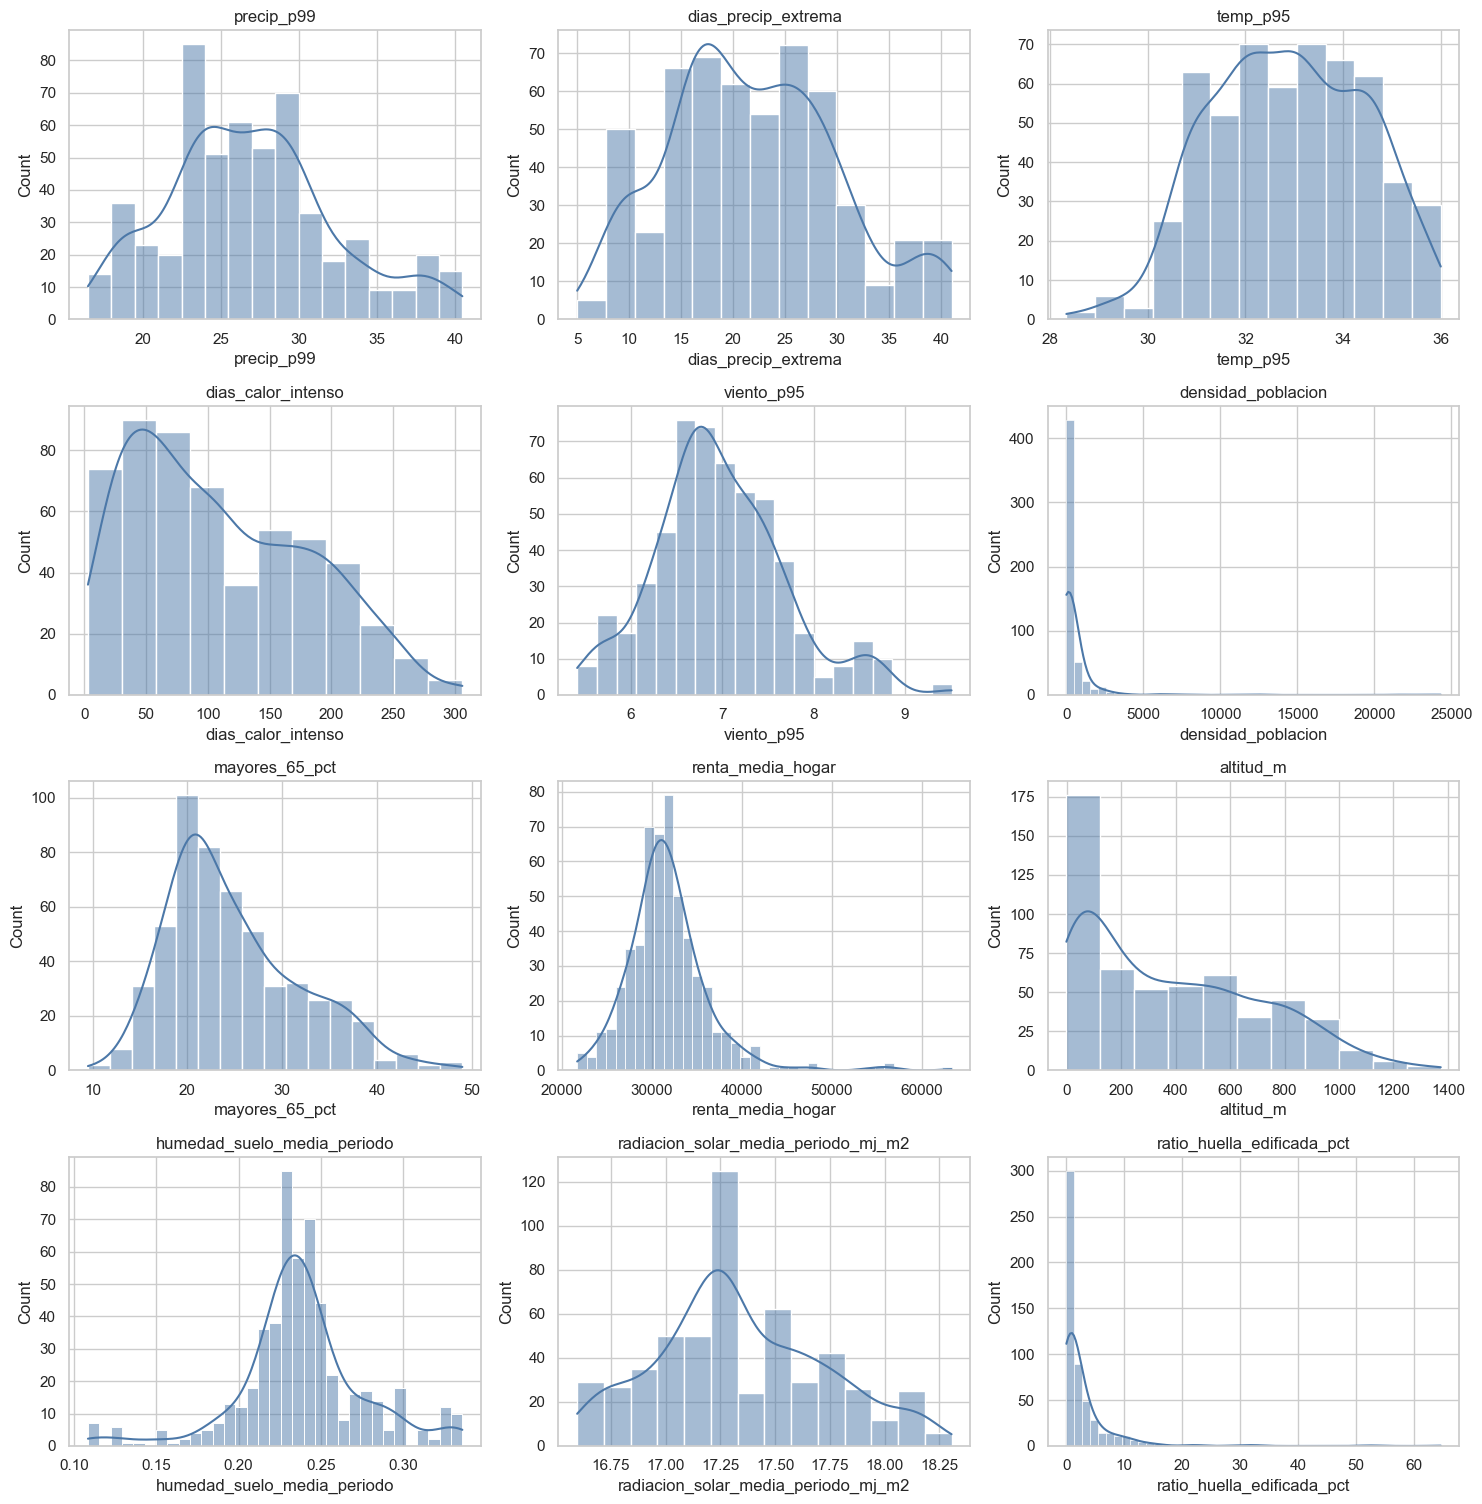

In [12]:
plot_cols = [
    "precip_p99",
    "dias_precip_extrema",
    "temp_p95",
    "dias_calor_intenso",
    "viento_p95",
    "densidad_poblacion",
    "mayores_65_pct",
    "renta_media_hogar",
    "altitud_m",
    "humedad_suelo_media_periodo",
    "radiacion_solar_media_periodo_mj_m2",
    "ratio_huella_edificada_pct",
]
plot_cols = [col for col in plot_cols if col in df_mun.columns]

n_cols = 3
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.8 * n_rows))
axes = np.array(axes).ravel()

for ax, col in zip(axes, plot_cols):
    sns.histplot(df_mun[col], kde=True, ax=ax, color="#4c78a8")
    ax.set_title(col)

for ax in axes[len(plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Las distribuciones obtenidas muestran que varios indicadores climaticos y territoriales no siguen un patron simetrico, sino que presentan colas largas o concentraciones de valores bajos con pocos municipios en niveles muy altos. Este comportamiento resulta especialmente visible en variables como `precip_p99`, `dias_precip_extrema` o `densidad_poblacion`, y sugiere que el territorio no puede interpretarse como un conjunto homogeneo.

Desde el punto de vista analitico, esta heterogeneidad refuerza el interes de comparar municipios destacados y de avanzar posteriormente hacia tecnicas de segmentacion o agrupacion.


In [13]:
ranking_cols = [
    "municipio",
    "precip_p99",
    "dias_precip_extrema",
    "temp_p95",
    "dias_calor_intenso",
    "viento_p95",
    "densidad_poblacion",
    "mayores_65_pct",
    "renta_media_hogar",
    "altitud_m",
    "humedad_suelo_media_periodo",
    "ratio_huella_edificada_pct",
]
ranking_cols = [col for col in ranking_cols if col in df_mun.columns]

print("Top municipios por precipitacion extrema (p99):")
display(df_mun.sort_values("precip_p99", ascending=False)[ranking_cols].head(15))

print("Top municipios por dias de calor intenso:")
display(df_mun.sort_values("dias_calor_intenso", ascending=False)[ranking_cols].head(15))

print("Top municipios por viento intenso (p95):")
display(df_mun.sort_values("viento_p95", ascending=False)[ranking_cols].head(15))

if "ratio_huella_edificada_pct" in df_mun.columns:
    print("Top municipios por ratio de huella edificada:")
    display(df_mun.sort_values("ratio_huella_edificada_pct", ascending=False)[ranking_cols].head(15))

Top municipios por precipitacion extrema (p99):


,municipio,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m,humedad_suelo_media_periodo,ratio_huella_edificada_pct
49,Almiserà,40.481348,41,33.088251,109,6.647643,37.22,25.71,31822.0,409.0,0.225982,0.3565
270,Llutxent,40.481348,41,33.088251,109,6.647643,57.67,22.06,31019.0,409.0,0.225982,0.6687
166,Castellonet de la Conquesta,40.481348,41,33.088251,109,6.647643,29.19,24.05,41936.0,409.0,0.225982,0.3030
6,Aielo de Rugat,40.481348,41,33.088251,109,6.647643,20.71,35.40,43758.0,409.0,0.225982,0.3573
377,Ròtova,40.481348,41,33.088251,109,6.647643,167.52,27.29,33863.0,409.0,0.225982,1.6506
100,Benicolet,40.481348,41,33.088251,109,6.647643,53.82,31.98,29760.0,409.0,0.225982,0.7769
424,Terrateig,40.481348,41,33.088251,109,6.647643,46.17,27.53,33030.0,409.0,0.225982,1.2457
298,Montitxelvo/Montichelvo,40.481348,41,33.088251,109,6.647643,67.42,24.60,32686.0,409.0,0.225982,0.7560
266,Llocnou de Sant Jeroni,40.481348,41,33.088251,109,6.647643,91.80,25.34,34039.0,409.0,0.225982,1.5196
477,Xeresa,39.056945,39,32.472809,83,7.446172,142.73,19.19,36055.0,135.0,0.287209,1.5287


Top municipios por dias de calor intenso:


,municipio,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m,humedad_suelo_media_periodo,ratio_huella_edificada_pct
360,Rafal,18.682162,10,36.000543,306,6.362503,3099.39,14.00,29469.0,17.0,0.278165,13.0943
199,Cox,18.682162,10,36.000543,306,6.362503,460.68,15.48,32330.0,17.0,0.278165,4.4180
365,Redován,18.682162,10,36.000543,306,6.362503,876.70,16.00,29722.0,17.0,0.278165,5.0426
132,Bigastro,18.682162,10,36.000543,306,6.362503,1839.14,16.18,30686.0,17.0,0.278165,9.3257
93,Benferri,17.933191,11,35.917022,285,6.263042,169.67,17.78,30649.0,180.0,0.182449,1.2469
247,Granja de Rocamora,18.123152,10,35.608819,265,6.391219,386.84,15.64,31126.0,84.0,0.203061,3.1262
15,Albatera,18.123152,10,35.608819,265,6.391219,219.23,15.97,29376.0,84.0,0.203061,1.4191
220,Estubeny,29.572659,26,35.687958,257,6.512214,17.13,34.55,27166.0,193.0,0.226403,0.2836
454,Vallés,29.572659,26,35.687958,257,6.512214,130.26,19.88,28947.0,193.0,0.226403,1.0956
374,Rotglà i Corberà,29.572659,26,35.687958,257,6.512214,186.71,22.09,32975.0,193.0,0.226403,1.9688


Top municipios por viento intenso (p95):


,municipio,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m,humedad_suelo_media_periodo,ratio_huella_edificada_pct
482,Xàbia/Jávea,29.636967,29,30.192072,9,9.511220,444.17,22.77,32978.0,108.0,0.284297,4.4094
239,Gata de Gorgos,29.636967,29,30.192072,9,9.511220,332.65,21.02,31582.0,108.0,0.284297,2.3401
211,Dénia,29.636967,29,30.192072,9,9.511220,711.07,21.26,33138.0,108.0,0.284297,4.8413
453,Vallibona,29.748676,27,30.636164,29,8.853558,0.69,25.40,26601.0,633.0,0.218846,0.0244
387,San Rafael del Río,29.374672,24,32.132782,60,8.841627,25.17,27.99,26443.0,283.0,0.249889,0.5168
154,Canet lo Roig,29.480974,27,31.431818,46,8.815587,10.40,33.62,28556.0,429.0,0.237003,0.1915
373,Rossell,29.480974,27,31.431818,46,8.815587,12.14,28.30,27148.0,429.0,0.237003,0.3589
343,Piles,36.642154,38,31.055512,39,8.684321,806.46,18.21,31100.0,11.0,0.294311,6.2247
289,Miramar,36.642154,38,31.055512,39,8.684321,1234.00,21.37,32129.0,11.0,0.294311,9.9970
314,Oliva,36.642154,38,31.055512,39,8.684321,445.35,21.98,31571.0,11.0,0.294311,3.2844


Top municipios por ratio de huella edificada:


,municipio,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m,humedad_suelo_media_periodo,ratio_huella_edificada_pct
267,Llocnou de la Corona,24.561298,17,33.280024,120,7.412632,10476.19,16.42,33832.0,13.0,0.327783,64.6723
215,Emperador,24.168112,18,33.107392,108,7.594843,24305.56,12.15,39021.0,0.0,0.336209,53.6153
92,Benetússer,24.561298,17,33.280024,120,7.412632,21451.10,19.36,32367.0,13.0,0.327783,51.6428
420,Tavernes Blanques,23.918967,16,33.069734,105,7.380803,12543.41,20.42,34022.0,29.0,0.296195,32.9321
9,Alaquàs,23.357834,16,33.381610,122,7.154692,7813.20,21.15,32487.0,72.0,0.230774,32.3449
290,Mislata,23.918967,16,33.069734,105,7.380803,23121.01,20.43,35060.0,29.0,0.296195,30.7877
141,Burjassot,23.918967,16,33.069734,105,7.380803,11941.99,18.40,32145.0,29.0,0.296195,28.9143
122,Beniparrell,24.561298,17,33.280024,120,7.412632,582.48,18.74,38980.0,13.0,0.327783,22.5486
398,Sedaví,24.561298,17,33.280024,120,7.412632,5938.41,21.02,35081.0,13.0,0.327783,22.1092
326,Paiporta,24.561298,17,33.280024,120,7.412632,7049.69,15.50,35308.0,13.0,0.327783,21.2341


Los rankings permiten identificar municipios que concentran niveles elevados en precipitacion extrema, calor intenso o viento fuerte. No obstante, estos resultados deben interpretarse con cautela, ya que varios municipios pueden compartir la misma coordenada climatica `ERA5-Land` y, por tanto, presentar valores identicos en algunos indicadores.

En consecuencia, los rankings no siempre reflejan diferencias climáticas completamente individualizadas entre municipios contiguos, sino tambien patrones territoriales compartidos derivados de la resolucion espacial del dataset.



Como contraste adicional, se construye una vista agregada por celda climatica `ERA5-Land`. Este bloque no sustituye el analisis municipal principal, sino que ayuda a interpretar mejor los rankings climaticos cuando varios municipios comparten la misma coordenada y, por tanto, presentan indicadores identicos o muy similares.

In [14]:
df_celdas_era5 = (
    df_mun.groupby(["lat", "lon"], as_index=False)
    .agg(
        n_municipios=("municipio", "size"),
        municipios=("municipio", lambda s: ", ".join(sorted(s))),
        precip_p99=("precip_p99", "first"),
        dias_precip_extrema=("dias_precip_extrema", "first"),
        temp_p95=("temp_p95", "first"),
        dias_calor_intenso=("dias_calor_intenso", "first"),
        viento_p95=("viento_p95", "first"),
        altitud_m=("altitud_m", "first"),
    )
)

print("Municipios totales:", len(df_mun))
print("Celdas ERA5-Land unicas:", len(df_celdas_era5))
print(
    "Celdas compartidas por mas de un municipio:",
    (df_celdas_era5["n_municipios"] > 1).sum()
)

display(
    df_celdas_era5.sort_values("precip_p99", ascending=False)[
        [
            "lat", "lon", "n_municipios", "municipios",
            "precip_p99", "dias_precip_extrema",
            "temp_p95", "dias_calor_intenso",
            "viento_p95", "altitud_m"
        ]
    ].head(15)
)


Municipios totales: 542
Celdas ERA5-Land unicas: 205
Celdas compartidas por mas de un municipio: 121


,lat,lon,n_municipios,municipios,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,altitud_m
61,38.9,-3.000000e-01,9,"Aielo de Rugat, Almiserà, Benicolet, Castellon...",40.481348,41,33.088251,109,6.647643,409.0
71,39.0,-2.000000e-01,6,"Benirredrà, Daimús, Gandia, Guardamar de la Sa...",39.056945,39,32.472809,83,7.446172,135.0
69,39.0,-4.000000e-01,2,"Barxeta, Quatretonda",38.506486,34,34.075360,160,6.480994,276.0
70,39.0,-3.000000e-01,3,"Barx, Pinet, Simat de la Valldigna",38.005026,36,33.066926,104,6.971375,685.0
62,38.9,-2.000000e-01,15,"Ador, Alfauir, Almoines, Bellreguard, Beniarjó...",37.833611,38,31.999384,68,7.682318,79.0
63,38.9,-1.000000e-01,3,"Miramar, Oliva, Piles",36.642154,38,31.055512,39,8.684321,11.0
60,38.9,-4.000000e-01,6,"Beniatjar, Castelló de Rugat, Otos, Rugat, Ráf...",36.637109,40,34.109473,160,6.157270,259.0
59,38.9,-5.000000e-01,9,"Alfarrasí, Bellús, Benissuera, Bufali, Bèlgida...",34.597036,32,34.721637,191,6.036749,193.0
50,38.8,-4.000000e-01,9,"Alcosser, Almudaina, Beniarrés, Benillup, Beni...",34.254530,29,33.661932,135,5.655909,364.0
51,38.8,-3.000000e-01,4,"Benimassot, Planes, Tollos, l'Orxa/Lorcha",33.644114,32,32.485004,74,6.151721,536.0


Esta vista complementaria por celda climatica confirma que una parte relevante de los patrones observados en los rankings responde a la resolucion espacial de `ERA5-Land`. Por tanto, los resultados del bloque deben interpretarse a dos niveles: como diferencias entre municipios en sus variables territoriales y como patrones climaticos compartidos entre municipios que utilizan la misma celda del reanalisis.

## 6. Relaciones entre clima, territorio y altitud

Una vez construidos los indicadores municipales, resulta util explorar si existen asociaciones entre las dimensiones climaticas y las variables territoriales incorporadas en el dataset enriquecido. En este bloque se analizan relaciones bivariantes entre indicadores de precipitacion, temperatura, viento, densidad, envejecimiento, renta y altitud.

El objetivo no es demostrar causalidad, sino identificar patrones descriptivos que ayuden a interpretar mejor la estructura del territorio y a orientar fases posteriores de segmentacion, construccion de indices y analisis de negocio.



La matriz de correlaciones se utiliza aqui como una herramienta diagnostica y exploratoria. Para facilitar su interpretacion, se selecciona un subconjunto de variables representativas y se evita incluir indicadores excesivamente redundantes entre si.

El objetivo de esta celda no es establecer relaciones causales, sino detectar asociaciones lineales que ayuden a entender la estructura del dataset y a orientar los analisis posteriores.


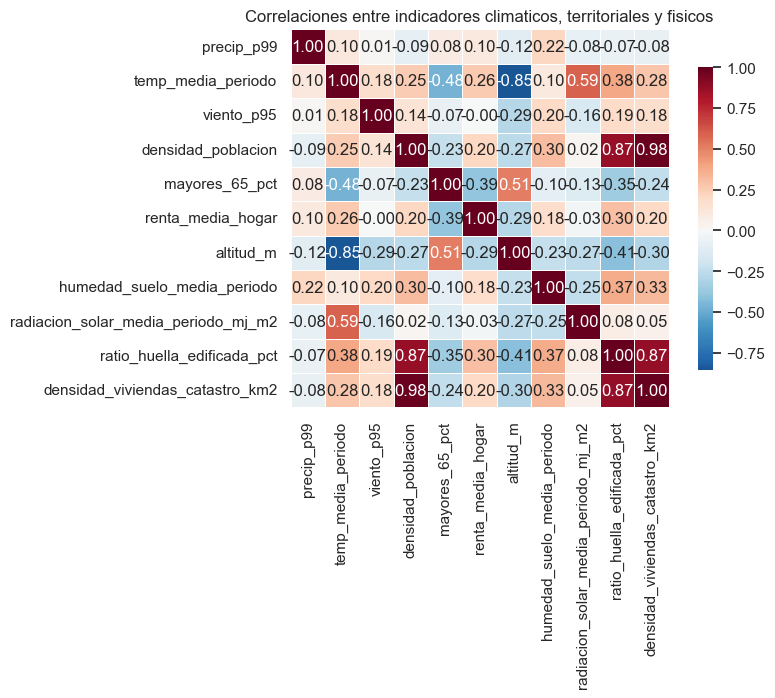

In [15]:
corr_cols = [
    "precip_p99",
    "temp_media_periodo",
    "viento_p95",
    "densidad_poblacion",
    "mayores_65_pct",
    "renta_media_hogar",
    "altitud_m",
    "humedad_suelo_media_periodo",
    "radiacion_solar_media_periodo_mj_m2",
    "ratio_huella_edificada_pct",
    "densidad_viviendas_catastro_km2",
]
corr_cols = [col for col in corr_cols if col in df_mun.columns]

corr = df_mun[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(max(9, len(corr_cols) * 0.8), max(7, len(corr_cols) * 0.65)))
sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlaciones entre indicadores climaticos, territoriales y fisicos")
plt.tight_layout()
plt.show()

La matriz confirma que la relacion mas clara del bloque aparece entre `altitud_m` y `temp_media_periodo`, con una asociacion negativa fuerte y coherente desde el punto de vista geografico. Tambien se observan asociaciones moderadas entre altitud, envejecimiento demografico y renta, lo que sugiere que ciertos patrones territoriales combinan rasgos climaticos y sociales.

En general, este resultado refuerza la idea de que el riesgo climático no debe interpretarse solo desde el clima, sino en combinacion con el contexto territorial y social de cada municipio.


In [16]:
df_mun["tramo_altitud"] = pd.cut(
    df_mun["altitud_m"],
    bins=[-10, 200, 400, 600, 800, np.inf],
    labels=["<=200 m", "200-400 m", "400-600 m", "600-800 m", "800+ m"],
    include_lowest=True,
)

display(
    df_mun["tramo_altitud"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame("municipios")
)

,municipios
tramo_altitud,
<=200 m,221
200-400 m,83
400-600 m,95
600-800 m,73
800+ m,70


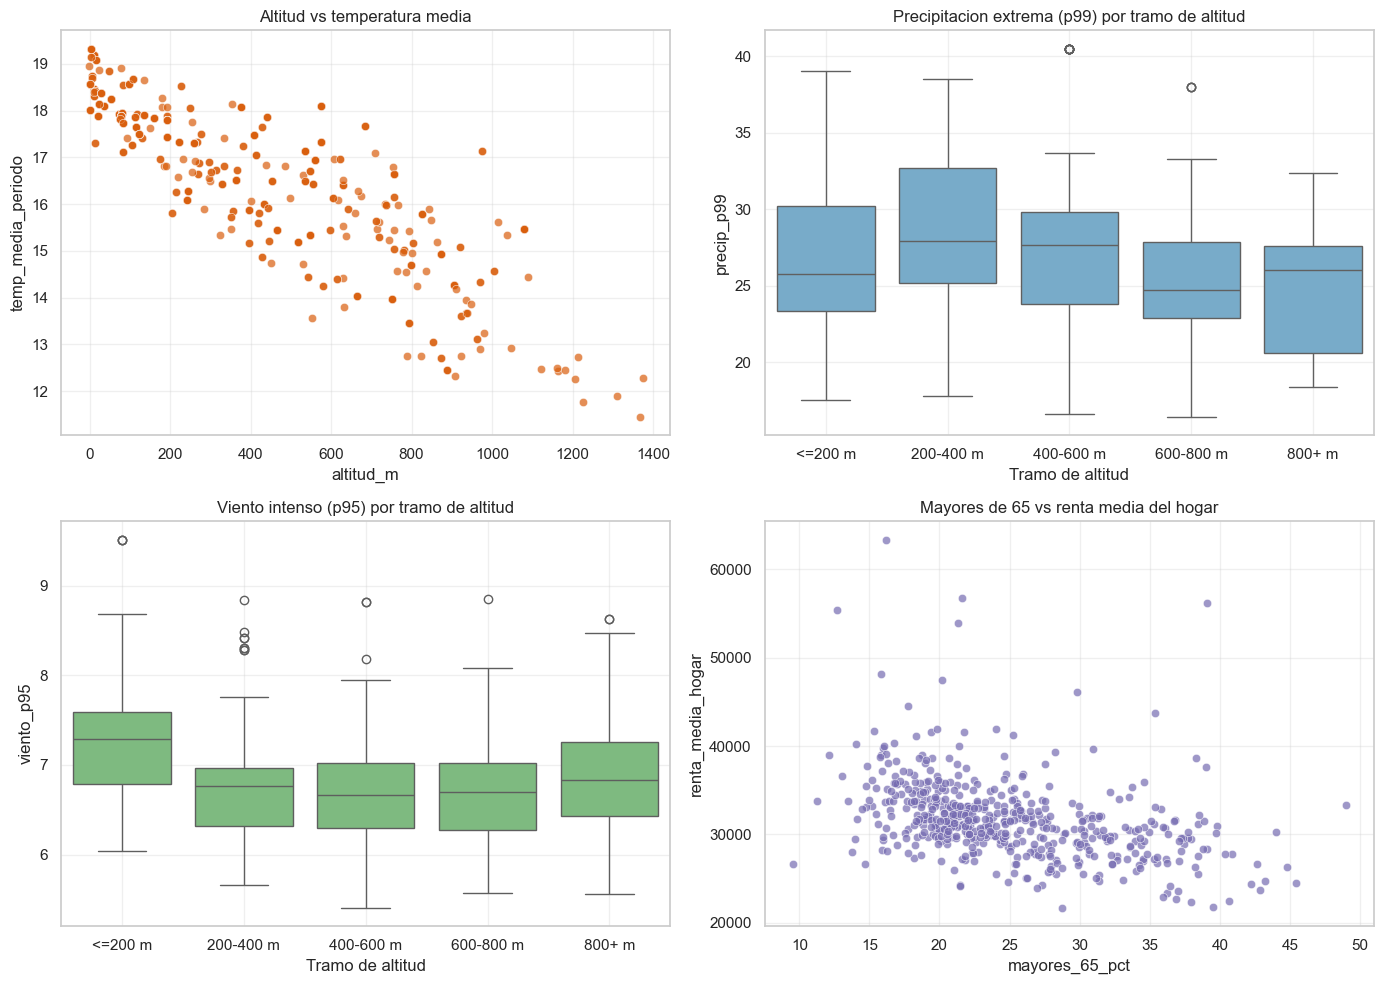

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(
    data=df_mun,
    x="altitud_m",
    y="temp_media_periodo",
    ax=axes[0, 0],
    color="#d95f0e",
    alpha=0.7,
)
axes[0, 0].set_title("Altitud vs temperatura media")

sns.boxplot(
    data=df_mun,
    x="tramo_altitud",
    y="precip_p99",
    ax=axes[0, 1],
    color="#6baed6",
)
axes[0, 1].set_title("Precipitacion extrema (p99) por tramo de altitud")
axes[0, 1].set_xlabel("Tramo de altitud")

sns.boxplot(
    data=df_mun,
    x="tramo_altitud",
    y="viento_p95",
    ax=axes[1, 0],
    color="#74c476",
)
axes[1, 0].set_title("Viento intenso (p95) por tramo de altitud")
axes[1, 0].set_xlabel("Tramo de altitud")

sns.scatterplot(
    data=df_mun,
    x="mayores_65_pct",
    y="renta_media_hogar",
    ax=axes[1, 1],
    color="#756bb1",
    alpha=0.7,
)
axes[1, 1].set_title("Mayores de 65 vs renta media del hogar")

for ax in axes.ravel():
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


La combinacion de diagramas de dispersion y boxplots permite representar de forma mas adecuada distintas dimensiones del riesgo climatico territorial. La relacion entre `altitud_m` y `temp_media_periodo` muestra una tendencia negativa clara y coherente con el comportamiento esperado entre elevacion y temperatura, lo que refuerza la plausibilidad geografica del dataset.

En el caso de la precipitacion extrema y del viento intenso, la representacion por tramos de altitud resulta mas informativa que un scatterplot simple, ya que evita que la mayor concentracion de municipios en cotas bajas distorsione visualmente la interpretacion. Estos boxplots permiten comparar mejor la distribucion de cada variable entre rangos de altitud y comprobar si existen diferencias territoriales relevantes en su intensidad.

Por ultimo, la relacion entre `mayores_65_pct` y `renta_media_hogar` introduce una lectura complementaria de vulnerabilidad social, relevante para interpretar el riesgo no solo como intensidad climatica, sino tambien como capacidad territorial de exposicion y respuesta.

## 7. Indices exploratorios de peligro climatico y vulnerabilidad

Con el fin de resumir la informacion municipal en una estructura mas interpretable, se construyen indices preliminares de peligro climatico y vulnerabilidad territorial. Estos indices no constituyen todavia un modelo final de riesgo, sino una herramienta exploratoria orientada a ordenar municipios y detectar combinaciones de intensidad climatica, exposicion y fragilidad territorial.

Para ello, se seleccionan variables representativas de distintos componentes del problema. El peligro climatico se aproxima mediante indicadores de precipitacion extrema, calor intenso y viento fuerte, mientras que la vulnerabilidad territorial se representa mediante densidad de poblacion, envejecimiento y renta. Dado que estas variables tienen escalas distintas, se normalizan previamente en un rango comun `0-1` mediante transformacion min-max.

La combinacion final de ambos bloques se plantea con un criterio heuristico y no calibrado, asignando un mayor peso al peligro climatico (`0.6`) que a la vulnerabilidad (`0.4`). Esta decision debe interpretarse como una simplificacion razonable para fines exploratorios, no como una ponderacion validada frente a datos reales de siniestralidad.



In [18]:
def minmax(series: pd.Series, reverse: bool = False) -> pd.Series:
    series = pd.to_numeric(series, errors="coerce")
    filled = series.fillna(series.median())
    spread = filled.max() - filled.min()
    if spread == 0:
        scaled = pd.Series(0.0, index=series.index)
    else:
        scaled = (filled - filled.min()) / spread
    return 1 - scaled if reverse else scaled

# Peligro climatico base: intensidad/frecuencia de precipitacion, calor y viento.
df_mun["score_precip"] = minmax(df_mun["precip_p99"])
df_mun["score_calor"] = minmax(df_mun["dias_calor_intenso"])
df_mun["score_viento"] = minmax(df_mun["viento_p95"])

df_mun["score_peligro_climatico"] = df_mun[["score_precip", "score_calor", "score_viento"]].mean(axis=1)

# Contexto climatico extendido: suelo seco, radiacion y escorrentia si existen.
extended_score_cols = []
if "dias_suelo_seco" in df_mun.columns:
    df_mun["score_suelo_seco"] = minmax(df_mun["dias_suelo_seco"])
    extended_score_cols.append("score_suelo_seco")
if "dias_radiacion_alta" in df_mun.columns:
    df_mun["score_radiacion_alta"] = minmax(df_mun["dias_radiacion_alta"])
    extended_score_cols.append("score_radiacion_alta")
if "dias_runoff_extremo" in df_mun.columns:
    df_mun["score_runoff_extremo"] = minmax(df_mun["dias_runoff_extremo"])
    extended_score_cols.append("score_runoff_extremo")

if extended_score_cols:
    df_mun["score_contexto_climatico_extendido"] = df_mun[extended_score_cols].mean(axis=1)
    df_mun["score_peligro_climatico_ampliado"] = (
        0.7 * df_mun["score_peligro_climatico"]
        + 0.3 * df_mun["score_contexto_climatico_extendido"]
    )
else:
    df_mun["score_contexto_climatico_extendido"] = np.nan
    df_mun["score_peligro_climatico_ampliado"] = df_mun["score_peligro_climatico"]

# Vulnerabilidad territorial: poblacion expuesta, envejecimiento y menor renta.
df_mun["score_densidad"] = minmax(df_mun["densidad_poblacion"])
df_mun["score_mayores"] = minmax(df_mun["mayores_65_pct"])
df_mun["score_renta_baja"] = minmax(df_mun["renta_media_hogar"], reverse=True)

df_mun["score_vulnerabilidad"] = df_mun[["score_densidad", "score_mayores", "score_renta_baja"]].mean(axis=1)

# Exposicion fisica: densidad edificada, viviendas y huella construida segun Catastro.
exposure_score_cols = []
if "densidad_edificios_km2" in df_mun.columns:
    df_mun["score_densidad_edificada"] = minmax(df_mun["densidad_edificios_km2"])
    exposure_score_cols.append("score_densidad_edificada")
if "densidad_viviendas_catastro_km2" in df_mun.columns:
    df_mun["score_densidad_viviendas"] = minmax(df_mun["densidad_viviendas_catastro_km2"])
    exposure_score_cols.append("score_densidad_viviendas")
if "ratio_huella_edificada_pct" in df_mun.columns:
    df_mun["score_huella_edificada"] = minmax(df_mun["ratio_huella_edificada_pct"])
    exposure_score_cols.append("score_huella_edificada")

if exposure_score_cols:
    df_mun["score_exposicion_fisica"] = df_mun[exposure_score_cols].mean(axis=1)
else:
    df_mun["score_exposicion_fisica"] = np.nan

# Se conserva el score preliminar original y se anade una version exploratoria ampliada.
df_mun["score_riesgo_preliminar"] = (
    0.6 * df_mun["score_peligro_climatico"]
    + 0.4 * df_mun["score_vulnerabilidad"]
)

df_mun["score_riesgo_exploratorio"] = (
    0.5 * df_mun["score_peligro_climatico_ampliado"]
    + 0.3 * df_mun["score_vulnerabilidad"]
    + 0.2 * df_mun["score_exposicion_fisica"].fillna(df_mun["score_vulnerabilidad"])
)

risk_display_cols = [
    "municipio",
    "score_peligro_climatico",
    "score_peligro_climatico_ampliado",
    "score_vulnerabilidad",
    "score_exposicion_fisica",
    "score_riesgo_preliminar",
    "score_riesgo_exploratorio",
    "precip_p99",
    "dias_calor_intenso",
    "viento_p95",
    "densidad_poblacion",
    "mayores_65_pct",
    "renta_media_hogar",
]
risk_display_cols = [col for col in risk_display_cols if col in df_mun.columns]

display(df_mun[risk_display_cols].sort_values("score_riesgo_exploratorio", ascending=False).head(20))

score_cols = [
    "score_precip",
    "score_calor",
    "score_viento",
    "score_peligro_climatico",
    "score_contexto_climatico_extendido",
    "score_peligro_climatico_ampliado",
    "score_densidad",
    "score_mayores",
    "score_renta_baja",
    "score_vulnerabilidad",
    "score_exposicion_fisica",
    "score_riesgo_preliminar",
    "score_riesgo_exploratorio",
]
score_cols = [col for col in score_cols if col in df_mun.columns]
display(df_mun[score_cols].describe().T)

,municipio,score_peligro_climatico,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_fisica,score_riesgo_preliminar,score_riesgo_exploratorio,precip_p99,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar
92,Benetússer,0.404112,0.347842,0.625274,0.646767,0.492577,0.490856,24.561298,120,7.412632,21451.10,19.36,32367.0
215,Emperador,0.400260,0.345037,0.550293,0.747165,0.460273,0.487039,24.168112,108,7.594843,24305.56,12.15,39021.0
267,Llocnou de la Corona,0.404112,0.347842,0.438218,0.819019,0.417754,0.469190,24.561298,120,7.412632,10476.19,16.42,33832.0
290,Mislata,0.376117,0.327184,0.635632,0.512166,0.479923,0.456715,23.918967,105,7.380803,23121.01,20.43,35060.0
507,l'Atzúbia,0.552879,0.519953,0.483333,0.006673,0.525060,0.406311,37.833611,68,7.682318,40.12,35.94,30891.0
21,Alcalalí,0.497655,0.474477,0.550479,0.011805,0.518785,0.404743,31.865981,27,8.576506,99.19,40.85,27781.0
500,els Poblets,0.497655,0.474477,0.484944,0.106444,0.492571,0.404010,31.865981,27,8.576506,748.17,35.28,31207.0
100,Benicolet,0.550649,0.523869,0.459171,0.007183,0.514058,0.401123,40.481348,109,6.647643,53.82,31.98,29760.0
80,Bellreguard,0.552879,0.519953,0.356009,0.148411,0.474131,0.396461,37.833611,68,7.682318,1770.21,19.01,31917.0
456,Venta del Moro,0.463490,0.463267,0.546350,0.000975,0.496634,0.395733,18.923543,238,7.508039,4.20,35.93,22952.0


,count,mean,std,min,25%,50%,75%,max
score_precip,542.0,0.436111,0.223947,0.000000,0.287580,0.429363,0.557557,1.000000
score_calor,542.0,0.351832,0.235481,0.000000,0.155116,0.323432,0.531353,1.000000
score_viento,542.0,0.381299,0.175414,0.000000,0.270143,0.365498,0.487874,1.000000
score_peligro_climatico,542.0,0.389747,0.101493,0.149928,0.298442,0.381184,0.475627,0.585852
score_contexto_climatico_extendido,542.0,0.307021,0.115687,0.094375,0.216613,0.288207,0.369996,0.681769
score_peligro_climatico_ampliado,542.0,0.364929,0.084249,0.190613,0.287132,0.356897,0.432340,0.523869
score_densidad,542.0,0.023838,0.084561,0.000000,0.000630,0.003585,0.016322,1.000000
score_mayores,542.0,0.389376,0.177189,0.000000,0.260504,0.346241,0.503037,1.000000
score_renta_baja,542.0,0.758591,0.109524,0.000000,0.714572,0.767284,0.815821,1.000000
score_vulnerabilidad,542.0,0.390601,0.077894,0.102197,0.342183,0.375900,0.439427,0.635632


Los resultados muestran que los scores construidos permiten distinguir municipios con combinaciones diferentes de peligro climatico y vulnerabilidad territorial. No obstante, estos indices deben interpretarse como una herramienta de priorizacion exploratoria y no como una medida definitiva de riesgo, ya que sus ponderaciones no han sido calibradas frente a siniestros reales.

Aun asi, esta aproximacion resulta util para generar una primera ordenacion territorial y preparar su representacion espacial en el bloque siguiente.


## 8. Representacion espacial

Se cruza la tabla municipal agregada con la geometria municipal para representar espacialmente algunos indicadores. Estos mapas permiten comprobar si los resultados muestran patrones territoriales coherentes.


In [19]:
gdf_mun = gpd.read_file(MUNICIPIOS_GEO_FILE)
risk_map_col = "score_riesgo_exploratorio" if "score_riesgo_exploratorio" in df_mun.columns else "score_riesgo_preliminar"

gdf_analysis = gdf_mun.merge(
    df_mun,
    on=["municipio", "CODNUT2", "CODNUT3"],
    how="left",
)

print("Municipios en geometria:", len(gdf_mun))
print("Municipios tras merge:", len(gdf_analysis))
print("Sin score de riesgo:", gdf_analysis[risk_map_col].isna().sum())

display_cols = ["municipio", risk_map_col, "score_peligro_climatico", "score_vulnerabilidad", "score_exposicion_fisica"]
display_cols = [col for col in display_cols if col in gdf_analysis.columns]
display(gdf_analysis[display_cols].head())

Municipios en geometria: 542
Municipios tras merge: 542
Sin score de riesgo: 0


,municipio,score_riesgo_exploratorio,score_peligro_climatico,score_vulnerabilidad,score_exposicion_fisica
0,l'Atzúbia,0.406311,0.552879,0.483333,0.006673
1,Agost,0.302003,0.276492,0.355532,0.007359
2,Agres,0.311068,0.418157,0.384731,0.004014
3,Aigües,0.272615,0.261318,0.334659,0.006399
4,Albatera,0.289251,0.391365,0.329444,0.014116


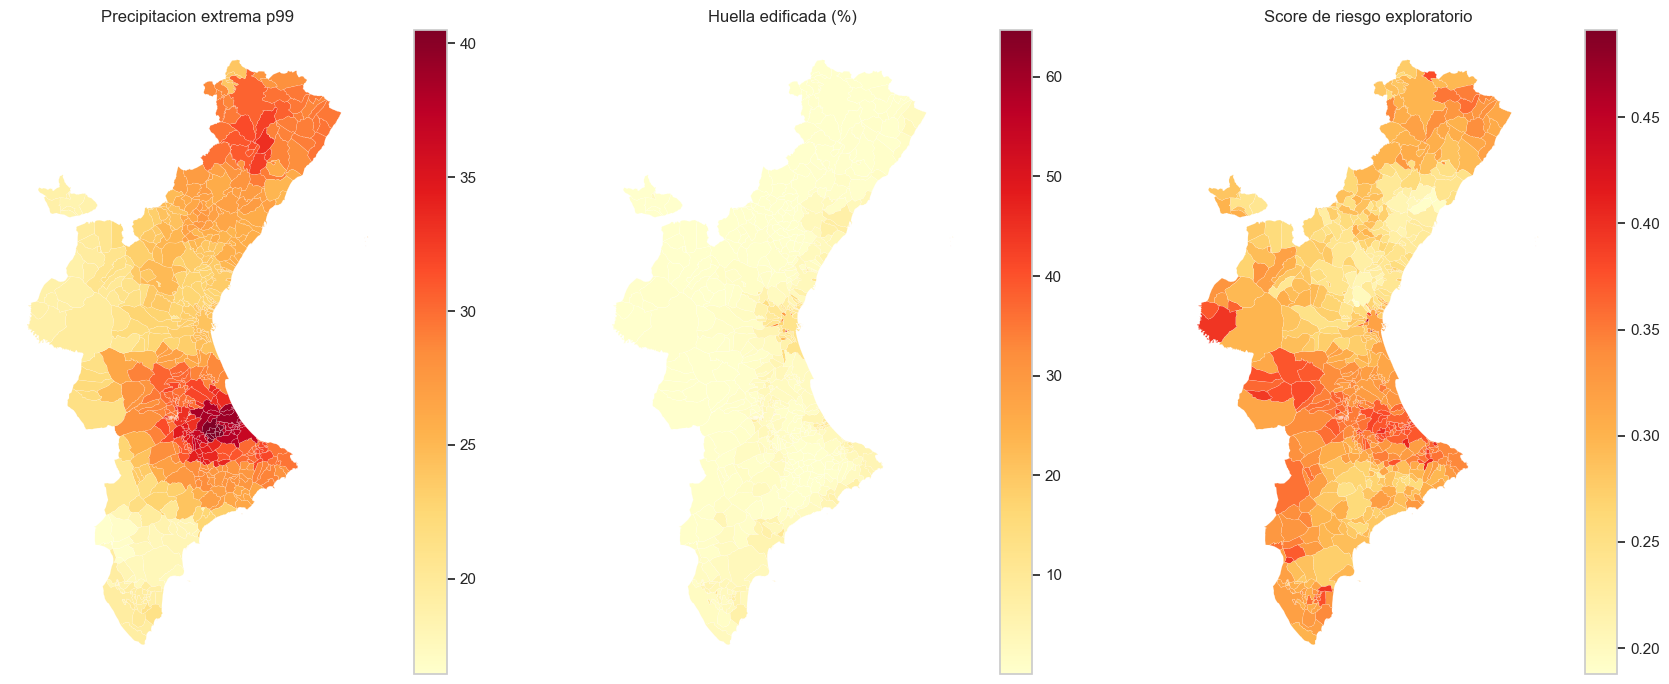

In [20]:
map_cols = [
    ("precip_p99", "Precipitacion extrema p99"),
    ("ratio_huella_edificada_pct", "Huella edificada (%)"),
    (risk_map_col, "Score de riesgo exploratorio"),
]
map_cols = [(col, title) for col, title in map_cols if col in gdf_analysis.columns]

fig, axes = plt.subplots(1, len(map_cols), figsize=(6 * len(map_cols), 7))
axes = np.array(axes).ravel()

for ax, (col, title) in zip(axes, map_cols):
    gdf_analysis.plot(
        column=col,
        ax=ax,
        legend=True,
        cmap="YlOrRd",
        linewidth=0.1,
        edgecolor="white",
        missing_kwds={"color": "lightgrey", "label": "Sin datos"},
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Mapa interactivo opcional si folium y sus dependencias estan instalados.
try:
    import folium

    interactive_file = MAPS / "mapa_riesgo_exploratorio.html"
    gdf_analysis_4326 = gdf_analysis.to_crs(epsg=4326)

    tooltip_cols = [
        "municipio",
        risk_map_col,
        "score_peligro_climatico",
        "score_vulnerabilidad",
        "score_exposicion_fisica",
        "precip_p99",
        "dias_calor_intenso",
        "densidad_poblacion",
        "ratio_huella_edificada_pct",
        "altitud_m",
    ]
    tooltip_cols = [col for col in tooltip_cols if col in gdf_analysis_4326.columns]

    m = gdf_analysis_4326.explore(
        column=risk_map_col,
        cmap="YlOrRd",
        legend=True,
        tooltip=tooltip_cols,
        style_kwds={"weight": 0.3, "fillOpacity": 0.75},
    )
    m.save(interactive_file)
    print("Mapa interactivo guardado en:", interactive_file)
except Exception:
    print("No se ha generado el mapa interactivo en este entorno. Queda como ampliacion futura del notebook.")

No se ha generado el mapa interactivo en este entorno. Queda como ampliacion futura del notebook.


La representacion espacial permite comprobar que los indicadores construidos no se distribuyen aleatoriamente, sino que muestran patrones territoriales diferenciados dentro de la Comunidad Valenciana. La precipitacion extrema, la densidad de poblacion y el score de riesgo preliminar presentan concentraciones espaciales que ayudan a identificar zonas donde coinciden intensidad climatica y vulnerabilidad territorial.

Este bloque no debe interpretarse como una zonificacion definitiva del riesgo, pero si como una evidencia visual de que el dataset permite detectar contrastes espaciales relevantes y preparar una lectura posterior orientada a segmentacion territorial y analisis de negocio.


## 9. Exportacion del dataset analitico municipal

La tabla municipal agregada se guarda como una salida estructurada del Notebook 3. Este fichero resume, para cada municipio, los principales indicadores climaticos, territoriales y exploratorios construidos a lo largo del analisis, por lo que resulta mas adecuado que la base diaria para tareas posteriores de ranking, representacion espacial, segmentacion territorial y modelizacion.



In [22]:
df_mun.to_csv(ANALYTIC_MUNICIPAL_FILE, index=False)

print("Dataset analitico municipal guardado en:", ANALYTIC_MUNICIPAL_FILE)
print("Shape:", df_mun.shape)
print("Columnas:", len(df_mun.columns))
print("Duplicados municipales:", df_mun.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum())

assert ANALYTIC_MUNICIPAL_FILE.exists(), "No se ha generado la salida analitica municipal."
assert len(df_mun) == 542, "La salida analitica debe tener una fila por municipio."
assert df_mun.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum() == 0, "La salida analitica contiene duplicados."

display(df_mun.head())

Dataset analitico municipal guardado en: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_analisis_municipal.csv
Shape: (542, 80)
Columnas: 80
Duplicados municipales: 0


,municipio,CODNUT2,CODNUT3,precip_media_diaria,precip_max_dia,precip_p95,precip_p99,dias_precip_intensa,dias_precip_extrema,temp_media_periodo,temp_max_media,temp_max_abs,temp_p95,dias_calor_intenso,temp_min_abs,viento_medio_periodo,viento_max_abs,viento_p95,dias_viento_intenso,amplitud_termica_media,lon,lat,dist_metros,area_km2,cod_ine,poblacion_total,densidad_poblacion,mayores_65_pct,menores_16_pct,indice_envejecimiento,renta_media_hogar,altitud_m,dewpoint_media_periodo,dewpoint_p95,presion_superficie_media_periodo_hpa,runoff_total_periodo_mm,runoff_p95_dia_mm,dias_runoff_extremo,humedad_suelo_media_periodo,humedad_suelo_p05,dias_suelo_seco,radiacion_solar_media_periodo_mj_m2,radiacion_solar_p95_mj_m2,dias_radiacion_alta,catastro_code,catastro_name,num_edificios_catastro,num_partes_edificio_catastro,num_otras_construcciones_catastro,huella_edificada_m2,superficie_construida_catastro_m2,num_unidades_edificatorias_catastro,num_viviendas_catastro,superficie_media_huella_edificio_m2,superficie_media_construida_edificio_m2,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,intensidad_constructiva_m2_km2,superficie_otras_construcciones_m2,tramo_altitud,score_precip,score_calor,score_viento,score_peligro_climatico,score_suelo_seco,score_radiacion_alta,score_runoff_extremo,score_contexto_climatico_extendido,score_peligro_climatico_ampliado,score_densidad,score_mayores,score_renta_baja,score_vulnerabilidad,score_densidad_edificada,score_densidad_viviendas,score_huella_edificada,score_exposicion_fisica,score_riesgo_preliminar,score_riesgo_exploratorio
0,Ademuz,ES52,ES523,1.459790,33.931183,8.618695,18.368174,105,6,12.317326,17.969816,37.645905,32.069465,60,-9.880951,2.354678,9.956327,6.782720,78,10.909306,-1.2,40.1,5806.682345,100.2900,46001,1015.0,10.12,26.80,11.82,226.67,27809.0,907.0,4.913211,17.229938,891.631791,49.566026,0.069138,88,0.256154,0.143142,0,17.075737,29.289683,250,46001,ADEMUZ,2057,3510,8,173331.35,456169.0,2625.0,1442.0,84.26,221.76,20.51,14.38,0.1728,4548.50,540.77,800+ m,0.079986,0.188119,0.335031,0.201045,0.000000,0.657718,0.228571,0.295430,0.229361,0.000388,0.437358,0.853748,0.430498,0.003093,0.001176,0.002296,0.002188,0.292826,0.244267
1,Ador,ES52,ES523,2.102830,143.414780,11.106972,37.833611,138,38,17.895431,21.608291,39.722076,31.999384,68,1.046295,3.106088,13.624233,7.682318,179,7.251112,-0.2,38.9,2485.383043,13.8364,46002,1755.0,126.84,20.42,11.36,179.70,31572.0,79.0,11.873880,22.513983,991.950788,293.414301,0.133204,145,0.241087,0.117641,537,17.545751,28.617354,225,46002,ADOR,902,2428,194,145267.88,283363.0,1433.0,982.0,161.05,314.15,65.19,70.97,1.0499,20479.53,8738.80,<=200 m,0.889841,0.214521,0.554274,0.552879,0.339444,0.489933,0.500000,0.443126,0.519953,0.005191,0.275880,0.763319,0.348130,0.011027,0.006435,0.015863,0.011108,0.470979,0.366637
2,Agost,ES52,ES521,1.094086,75.414550,5.610108,18.520694,75,11,18.075257,22.611731,39.302155,32.961835,97,-0.357025,2.732337,13.176444,7.184352,117,8.828438,-0.6,38.4,6996.059580,66.6538,03002,5225.0,78.39,20.27,13.84,146.47,30407.0,181.0,11.058666,22.072614,993.317850,74.163252,0.040480,62,0.108358,0.025569,1505,18.002993,29.056239,284,3002,AGOST,2384,5488,440,548999.50,871050.0,4586.0,2919.0,230.29,365.37,35.77,43.79,0.8237,13068.27,17005.18,<=200 m,0.086332,0.310231,0.432913,0.276492,0.951327,0.885906,0.104762,0.647332,0.387744,0.003197,0.272083,0.791315,0.355532,0.005803,0.003909,0.012364,0.007359,0.308108,0.302003
3,Agres,ES52,ES521,1.826327,106.037970,9.551134,31.017301,123,28,16.650944,22.090261,42.157623,34.419501,176,-3.486420,1.976098,9.044077,5.725050,22,10.334956,-0.5,38.8,2075.930152,25.8457,03003,623.0,24.10,24.80,11.36,218.31,31440.0,756.0,9.273725,20.648029,963.881222,210.584266,0.086536,114,0.241691,0.140176,0,17.565828,28.791113,244,3003,AGRES,663,1384,80,106531.09,206125.0,864.0,611.0,160.68,310.90,25.65,23.64,0.4122,7975.21,3331.63,600-800 m,0.606250,0.570957,0.077263,0.418157,0.000000,0.617450,0.352381,0.323277,0.38

## 10. Conclusiones provisionales del analisis

El analisis realizado en este notebook confirma que el dataset municipal construido en las fases anteriores presenta una estructura suficientemente coherente y rica como para sostener una lectura territorial del riesgo climatico en la Comunidad Valenciana. La serie temporal agregada muestra patrones estacionales plausibles en temperatura, precipitacion y viento, mientras que la agregacion municipal permite comparar los municipios mediante indicadores homogeneos de intensidad, frecuencia y contexto territorial.

La incorporacion de variables extendidas de `ERA5-Land` mejora la lectura fisica del territorio, ya que permite observar informacion complementaria sobre humedad del suelo, radiacion, punto de rocio, presion y escorrentia. A su vez, el resumen de Catastro introduce una aproximacion a la exposicion edificada, diferenciando municipios no solo por su poblacion o renta, sino tambien por la concentracion de construcciones, viviendas y huella edificada.

Los resultados obtenidos muestran que el riesgo climatico no puede interpretarse unicamente desde una variable aislada. La temperatura presenta una relacion clara con la altitud, la precipitacion extrema y el viento intenso muestran distribuciones espaciales diferenciadas, y las variables demograficas, socioeconomicas y de exposicion fisica introducen dimensiones adicionales de vulnerabilidad territorial. En este sentido, la combinacion entre peligro climatico, vulnerabilidad y exposicion permite construir una primera ordenacion exploratoria de municipios que resulta util para fases posteriores del trabajo.

No obstante, este bloque sigue teniendo caracter exploratorio. Los indices construidos no deben entenderse como una medida definitiva de riesgo, ya que sus ponderaciones son heuristicas y no han sido calibradas frente a siniestros reales. Por ello, la siguiente fase del proyecto deberia profundizar en tecnicas de segmentacion, comparacion entre grupos de municipios y analisis orientado a negocio, con el fin de traducir estos hallazgos en conclusiones mas aplicables.